Error reading from MySQL: Execution failed on sql 'SELECT * FROM aqi_data': (pymysql.err.ProgrammingError) (1146, "Table 'hanoi_aqi.aqi_data' doesn't exist")
[SQL: SELECT * FROM aqi_data]
(Background on this error at: https://sqlalche.me/e/20/f405). Falling back to CSV...
Số dòng dữ liệu để clustering: 30336
Các feature sử dụng: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed']



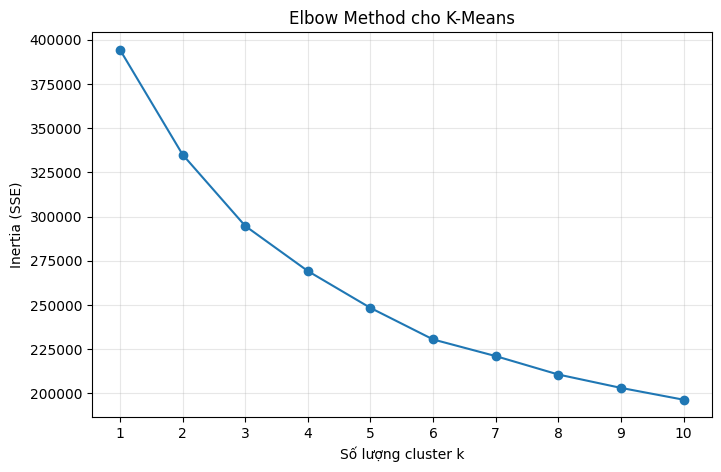

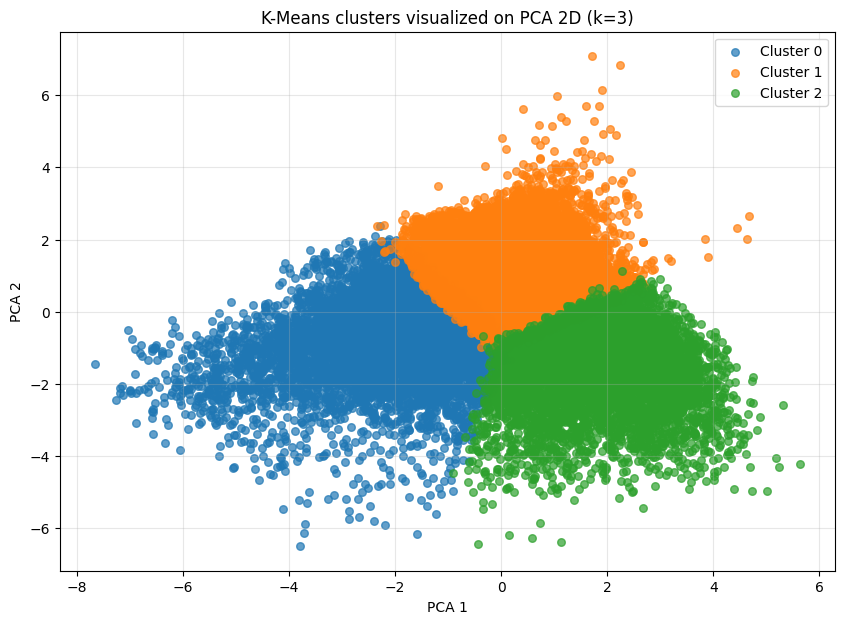



CLUSTER CENTROIDS (original scale):
             co    no2      o3    pm10   pm25    so2  clouds  precipitation  pressure  relative_humidity  temperature  uv_index  wind_speed
cluster                                                                                                                                    
0        350.60  43.87   41.79  120.40  86.52  80.83   78.56           0.08   1017.39              76.18        19.17      0.73        1.56
1        413.27  24.35   41.65   45.74  33.77  47.40   72.74           0.40   1007.12              85.84        25.92      0.64        1.78
2        183.41  13.36  111.73   53.72  40.45  73.59   57.70           0.12   1007.42              61.23        29.77      3.57        2.05


CLUSTER PROFILE REPORT:
            co                                 no2                               o3                              pm10                               pm25                              so2                            clouds                 

In [ ]:

import joblib
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

try:
    # Kết nối MySQL và đọc dữ liệu trực tiếp từ database
    engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
    df = pd.read_sql('SELECT * FROM aqi_data', con=engine)
    print(f"Đã đọc {len(df):,} hàng từ MySQL")
    engine.dispose()
except Exception as e:
    print(f"Error reading from MySQL: {e}. Falling back to CSV...")
    try:
        df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv', low_memory=False, on_bad_lines='skip')
    except Exception as e:
        print(f"Error reading cleaned file: {e}")
        files = ['../data_raw/2022.csv', '../data_raw/2023.csv', '../data_raw/2024.csv', '../data_raw/2025.csv']
        df_list = []
        for f in files:
            try:
                df_list.append(pd.read_csv(f, low_memory=False, on_bad_lines='skip'))
            except:
                pass
        df = pd.concat(df_list, ignore_index=True)

df.columns = df.columns.str.strip().str.lower()

if 'local_time' in df.columns and 'date' not in df.columns:
    df = df.rename(columns={'local_time': 'date'})

df['date'] = pd.to_datetime(df['date'], errors='coerce')
SEASON_MAP = {0: 'Đông', 1: 'Xuân', 2: 'Hè', 3: 'Thu'}

# 2. CHUẨN BỊ FEATURE VÀ CHUẨN HÓA DỮ LIỆU
feature_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
                'precipitation', 'pressure', 'relative_humidity', 
                'temperature', 'uv_index', 'wind_speed']

X = df[feature_cols]
print(f"Số dòng dữ liệu để clustering: {len(X)}")
print(f"Các feature sử dụng: {feature_cols}\n")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. ELBOW METHOD (TÌM K TỐI ƯU)
inertia = []
ks = list(range(1, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertia, marker='o')
plt.xticks(ks)
plt.xlabel('Số lượng cluster k')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method cho K-Means')
plt.grid(alpha=0.3)
plt.show()

print('\n' + '='*80 + '\n')

# 4. K-MEANS CLUSTERING VỚI K=3
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

# 5. TRỰC QUAN HÓA BẰNG PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=k_opt)
for cluster_id in sorted(np.unique(labels)):
    mask = labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[palette[cluster_id]], s=30, alpha=0.7, label=f'Cluster {cluster_id}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'K-Means clusters visualized on PCA 2D (k={k_opt})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('\n' + '='*80 + '\n')

# 6. BÁO CÁO ĐẶC TRƯNG CÁC CỤM (CLUSTER PROFILE)
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=X.columns)
cluster_centers.index.name = 'cluster'

print('CLUSTER CENTROIDS (original scale):')
print(cluster_centers.round(2))
print('\n' + '='*80 + '\n')

clustered_df = df.copy()
clustered_df['cluster'] = labels

profile_report = clustered_df.groupby('cluster')[feature_cols].agg(['count', 'mean', 'std', 'min', 'max'])
print('CLUSTER PROFILE REPORT:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
    print(profile_report.round(2).to_string())

print('\n' + '='*80 + '\n')

# 7. ĐÁNH GIÁ MÔ HÌNH (TÍNH SILHOUETTE SCORE)
print('ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM:')
sil_score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
print(f'✨ Silhouette Score (on 5000 sample): {sil_score:.3f} (higher is better, range: [-1, 1])')
print('\n' + '='*80 + '\n')

# 8. PHÂN TÍCH ĐẶC TRƯNG THỜI GIAN VÀ AQI
if 'hour' not in clustered_df.columns and 'date' in clustered_df.columns:
    clustered_df['hour'] = clustered_df['date'].dt.hour
if 'month' not in clustered_df.columns and 'date' in clustered_df.columns:
    clustered_df['month'] = clustered_df['date'].dt.month
if 'season' in clustered_df.columns:
    clustered_df['season_name'] = clustered_df['season'].map(SEASON_MAP)

print('CLUSTER SIZE:')
print(clustered_df['cluster'].value_counts().sort_index())
print()

if 'aqi' in clustered_df.columns:
    print('MEAN AQI BY CLUSTER:')
    print(clustered_df.groupby('cluster')['aqi'].agg(['mean', 'std', 'min', 'max']).round(2))
    print()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)

if 'season_name' in clustered_df.columns:
    print('CLUSTER DISTRIBUTION BY SEASON (Full Table):')
    season_table = clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0)
    print(season_table.to_string())
    print()

if 'hour' in clustered_df.columns:
    print('CLUSTER DISTRIBUTION BY HOUR (Full 24 Hours):')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts.to_string())
    print()
    
    print('Hour with most members in each cluster:')
    top_hours = hour_counts.idxmax(axis=1)
    print(top_hours.to_string())
    print()

if 'aqi' in clustered_df.columns:
    print('CLUSTERS RANKED BY MEAN AQI:')
    aqi_cluster = clustered_df.groupby('cluster')['aqi'].mean().sort_values(ascending=False)
    print(aqi_cluster.round(2).to_string())

In [4]:
import pandas as pd

# Show full table output instead of truncated notebook display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

if 'season_name' in clustered_df.columns:
    print('\nCluster distribution by season (full table):')
    season_table = clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0)
    print(season_table.to_string())

if 'hour' in clustered_df.columns:
    print('\nCluster distribution by hour (full table):')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts.to_string())
    top_hours = hour_counts.idxmax(axis=1)
    print('\nHour with most members in each cluster:')
    print(top_hours.to_string())

if 'aqi' in clustered_df.columns:
    print('\nClusters ranked by mean AQI:')
    print(aqi_cluster.round(2).to_string())


Cluster distribution by season (full table):
season_name    Hè   Thu  Xuân  Đông
cluster                            
0              42  1457  1937  5089
1            5006  3172  4948  1874
2            2296  1923  1947   645

Cluster distribution by hour (full table):
hour      0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23
cluster                                                                                                                        
0        423  407  415  425  406  422  428  420  444  401  309  273  229  181  198  199  181  267  363  410  433  439  425  427
1        836  852  847  837  856  838  826  828  732  545  384  293  234  211  260  308  359  460  580  709  759  792  821  833
2          5    5    2    2    2    4   10   16   88  318  571  698  801  872  806  757  724  537  321  145   72   33   18    4

Hour with most members in each cluster:
cluster
0     8
1     4
2    13

Clusters ranked 